In [316]:
import pandas as pd 
import numpy as np
import os 
import matplotlib.pyplot as plt 

In [350]:
filepaths = [f for f in os.listdir(".") if f.endswith('.csv')]
df = pd.concat([pd.read_csv(file) for file in filepaths])

In [351]:
df

,rt,response,trial_type,trial_index,plugin_version,time_elapsed,correct,training,stimulus,correct_response,timestamp
0,20446,"{""age"":""""}",survey-text,1,2.1.0,587782,NaN,NaN,NaN,NaN,NaN
1,9621,x,audio-keyboard-response,6,2.1.0,633412,x,True,data/A/output39-6.wav,True,NaN
2,9029,m,audio-keyboard-response,8,2.1.0,645124,m,True,data/H/244.15-6.wav,True,NaN
3,12661,m,audio-keyboard-response,10,2.1.0,660725,x,False,data/A/output3-3.wav,NaN,2026-01-23T10-36-57-818Z
4,10520,x,audio-keyboard-response,11,2.1.0,672036,m,False,data/H/276-8.wav,NaN,2026-01-23T10-36-57-818Z
...,...,...,...,...,...,...,...,...,...,...,...
19,11229,x,audio-keyboard-response,26,2.1.0,471340,m,False,data/H/227.11-5.wav,NaN,2026-01-23T14-08-11-023Z
20,9509,m,audio-keyboard-response,27,2.1.0,481396,m,False,data/H/290-2.wav,NaN,2026-01-23T14-08-11-023Z
21,11109,m,audio-keyboard-response,28,2.1.0,493036,m,False,data/H/283-7.wav,NaN,2026-01-23T14-08-11-023Z
22,10259,x,audio-keyboard-response,29,2.1.0,503845,m,False,data/H/153.5-3.wav,NaN,2026-01-23T14-08-11-023Z


In [352]:
df.sample(10)

,rt,response,trial_type,trial_index,plugin_version,time_elapsed,correct,training,stimulus,correct_response,timestamp
10,9019,x,audio-keyboard-response,17,2.1.0,280771,m,False,data/H/175.5-5.wav,NaN,2026-01-23T10-44-30-154Z
23,50875,"{""Q0"":""Sehr kreativ und schön umgesetzt. ""}",survey-text,30,2.1.0,712525,NaN,NaN,NaN,NaN,NaN
23,93493,"{""Q0"":""es hat total spaß gemacht auch wenn ich...",survey-text,30,2.1.0,546236,NaN,NaN,NaN,NaN,NaN
5,10931,m,audio-keyboard-response,12,2.1.0,339364,m,False,data/H/290-2.wav,NaN,2026-01-23T14-08-20-701Z
10,9549,m,audio-keyboard-response,17,2.1.0,355444,m,False,data/H/256-5.wav,NaN,2026-01-23T14-09-05-481Z
3,10251,m,audio-keyboard-response,10,2.1.0,322117,m,False,data/H/292-2.wav,NaN,2026-01-23T14-08-20-701Z
15,12200,x,audio-keyboard-response,22,2.1.0,264928,x,False,data/A/output19-1.wav,NaN,2026-01-23T14-13-05-342Z
1,3112,m,audio-keyboard-response,6,2.1.0,141653,m,True,data/H/292-2.wav,True,NaN
16,9091,m,audio-keyboard-response,23,2.1.0,779980,x,False,data/A/output19-1.wav,NaN,2026-01-23T10-36-57-818Z
9,6989,x,audio-keyboard-response,16,2.1.0,715196,x,False,data/A/output14-6.wav,NaN,2026-01-23T10-36-57-818Z


In [353]:
survey_text = df[df["trial_type"].str.contains("survey-text")]

Mean:  24.612903225806452
Median:  20.0


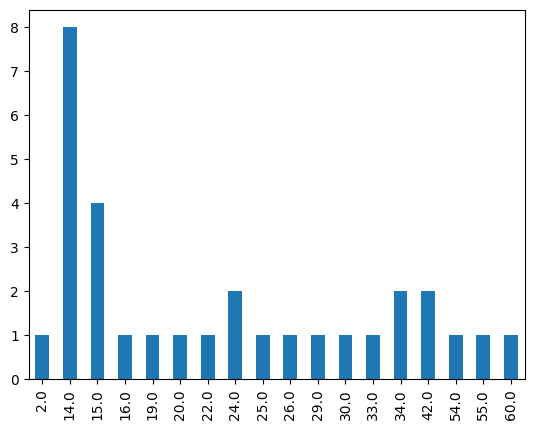

In [354]:
ages = pd.Series([ eval(item)["age"] for item in list(survey_text["response"].values) if "age" in eval(item).keys() ])
ages = ages.map(lambda x: int(x.strip()) if x != '' else None).sort_values()

idx = np.arange(0, ages.max())
ages.value_counts().sort_index().plot(kind="bar")
print("Mean: ", ages.mean())
print("Median: ", ages.median())

In [355]:
survey_text

,rt,response,trial_type,trial_index,plugin_version,time_elapsed,correct,training,stimulus,correct_response,timestamp
0,20446,"{""age"":""""}",survey-text,1,2.1.0,587782,NaN,NaN,NaN,NaN,NaN
23,6430,"{""Q0"":""""}",survey-text,30,2.1.0,853132,NaN,NaN,NaN,NaN,NaN
0,5791,"{""age"":""25""}",survey-text,1,2.1.0,121107,NaN,NaN,NaN,NaN,NaN
23,4214,"{""Q0"":""""}",survey-text,30,2.1.0,406671,NaN,NaN,NaN,NaN,NaN
0,3422,"{""age"":""24""}",survey-text,1,2.1.0,217894,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
23,21191,"{""Q0"":""Sehr schwer für Ungeübte\n""}",survey-text,30,2.1.0,518445,NaN,NaN,NaN,NaN,NaN
0,4614,"{""age"":""14""}",survey-text,1,2.1.0,166159,NaN,NaN,NaN,NaN,NaN
23,156973,"{""Q0"":""Es hat Spaß gemacht und es wurde gut er...",survey-text,30,2.1.0,600170,NaN,NaN,NaN,NaN,NaN
0,2303,"{""age"":""34""}",survey-text,1,2.1.0,174988,NaN,NaN,NaN,NaN,NaN


In [323]:
df.shape

(768, 11)

In [356]:
## remove empty timestamps: test runs
df = df[df["timestamp"].notnull()].reset_index()
df.head()

,index,rt,response,trial_type,trial_index,plugin_version,time_elapsed,correct,training,stimulus,correct_response,timestamp
0,3,12661,m,audio-keyboard-response,10,2.1.0,660725,x,False,data/A/output3-3.wav,NaN,2026-01-23T10-36-57-818Z
1,4,10520,x,audio-keyboard-response,11,2.1.0,672036,m,False,data/H/276-8.wav,NaN,2026-01-23T10-36-57-818Z
2,5,8040,m,audio-keyboard-response,12,2.1.0,680804,m,False,data/H/175.5-5.wav,NaN,2026-01-23T10-36-57-818Z
3,6,7709,m,audio-keyboard-response,13,2.1.0,689108,m,False,data/H/283-7.wav,NaN,2026-01-23T10-36-57-818Z
4,7,5221,x,audio-keyboard-response,14,2.1.0,694980,x,False,data/A/output28-2.wav,NaN,2026-01-23T10-36-57-818Z


In [357]:
df.shape

(640, 12)

In [358]:
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%Y-%m-%dT%H-%M-%S-%fZ", utc=True)
df.head()

,index,rt,response,trial_type,trial_index,plugin_version,time_elapsed,correct,training,stimulus,correct_response,timestamp
0,3,12661,m,audio-keyboard-response,10,2.1.0,660725,x,False,data/A/output3-3.wav,NaN,2026-01-23 10:36:57.818000+00:00
1,4,10520,x,audio-keyboard-response,11,2.1.0,672036,m,False,data/H/276-8.wav,NaN,2026-01-23 10:36:57.818000+00:00
2,5,8040,m,audio-keyboard-response,12,2.1.0,680804,m,False,data/H/175.5-5.wav,NaN,2026-01-23 10:36:57.818000+00:00
3,6,7709,m,audio-keyboard-response,13,2.1.0,689108,m,False,data/H/283-7.wav,NaN,2026-01-23 10:36:57.818000+00:00
4,7,5221,x,audio-keyboard-response,14,2.1.0,694980,x,False,data/A/output28-2.wav,NaN,2026-01-23 10:36:57.818000+00:00


In [359]:
for name, group in df.groupby("timestamp"):
    print(group.shape)

print(df["timestamp"].nunique())

(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
(20, 12)
32


In [328]:
df.columns

Index(['index', 'rt', 'response', 'trial_type', 'trial_index',
       'plugin_version', 'time_elapsed', 'correct', 'training', 'stimulus',
       'correct_response', 'timestamp'],
      dtype='object')

In [360]:
df = df[[
    'index', 
    'timestamp',
    'trial_type',
    # 'trial_index',
    'time_elapsed',
    'stimulus',
    # 'training',
    'response',  
    'correct',
    'correct_response',
    'rt', 
    # 'plugin_version',
        ]]

In [361]:
df.head()

,index,timestamp,trial_type,time_elapsed,stimulus,response,correct,correct_response,rt
0,3,2026-01-23 10:36:57.818000+00:00,audio-keyboard-response,660725,data/A/output3-3.wav,m,x,NaN,12661
1,4,2026-01-23 10:36:57.818000+00:00,audio-keyboard-response,672036,data/H/276-8.wav,x,m,NaN,10520
2,5,2026-01-23 10:36:57.818000+00:00,audio-keyboard-response,680804,data/H/175.5-5.wav,m,m,NaN,8040
3,6,2026-01-23 10:36:57.818000+00:00,audio-keyboard-response,689108,data/H/283-7.wav,m,m,NaN,7709
4,7,2026-01-23 10:36:57.818000+00:00,audio-keyboard-response,694980,data/A/output28-2.wav,x,x,NaN,5221


In [362]:
df["timestamp"].unique()

<DatetimeArray>
['2026-01-23 10:36:57.818000+00:00', '2026-01-23 10:44:30.154000+00:00',
 '2026-01-23 14:19:08.520000+00:00', '2026-01-23 14:00:50.672000+00:00',
 '2026-01-23 14:12:01.395000+00:00', '2026-01-23 14:02:56.171000+00:00',
 '2026-01-23 14:09:05.481000+00:00', '2026-01-23 13:58:34.029000+00:00',
 '2026-01-23 10:35:23.239000+00:00', '2026-01-23 14:25:10.962000+00:00',
 '2026-01-23 14:11:02.880000+00:00', '2026-01-23 13:58:24.506000+00:00',
 '2026-01-23 14:08:20.701000+00:00', '2026-01-23 14:19:14.897000+00:00',
 '2026-01-23 14:11:57.709000+00:00', '2026-01-23 14:05:47.528000+00:00',
 '2026-01-23 14:21:34.148000+00:00', '2026-01-23 14:28:49.967000+00:00',
 '2026-01-23 14:09:25.129000+00:00', '2026-01-23 13:58:22.093000+00:00',
 '2026-01-23 14:20:06.283000+00:00', '2026-01-23 14:21:05.146000+00:00',
 '2026-01-23 14:17:45.211000+00:00', '2026-01-23 14:18:16.482000+00:00',
 '2026-01-23 10:45:38.073000+00:00', '2026-01-23 14:27:19.028000+00:00',
 '2026-01-23 14:10:23.701000+00:00'

In [363]:
df = df.sort_values(by=["timestamp", "index"])
df.head()

,index,timestamp,trial_type,time_elapsed,stimulus,response,correct,correct_response,rt
160,3,2026-01-23 10:35:23.239000+00:00,audio-keyboard-response,738677,data/H/276-8.wav,m,m,NaN,12600
161,4,2026-01-23 10:35:23.239000+00:00,audio-keyboard-response,750605,data/H/256-5.wav,x,m,NaN,11149
162,5,2026-01-23 10:35:23.239000+00:00,audio-keyboard-response,765405,data/A/output28-2.wav,m,x,NaN,13909
163,6,2026-01-23 10:35:23.239000+00:00,audio-keyboard-response,777581,data/H/283-7.wav,x,m,NaN,11579
164,7,2026-01-23 10:35:23.239000+00:00,audio-keyboard-response,788877,data/H/290-2.wav,m,m,NaN,10720


In [365]:
df["correct_response"] = df["response"] == df["correct"]

In [366]:
df.head()

,index,timestamp,trial_type,time_elapsed,stimulus,response,correct,correct_response,rt
160,3,2026-01-23 10:35:23.239000+00:00,audio-keyboard-response,738677,data/H/276-8.wav,m,m,True,12600
161,4,2026-01-23 10:35:23.239000+00:00,audio-keyboard-response,750605,data/H/256-5.wav,x,m,False,11149
162,5,2026-01-23 10:35:23.239000+00:00,audio-keyboard-response,765405,data/A/output28-2.wav,m,x,False,13909
163,6,2026-01-23 10:35:23.239000+00:00,audio-keyboard-response,777581,data/H/283-7.wav,x,m,False,11579
164,7,2026-01-23 10:35:23.239000+00:00,audio-keyboard-response,788877,data/H/290-2.wav,m,m,True,10720


In [367]:
responses_indiv = pd.Series([g["correct_response"].sum() for n, g in df.groupby("timestamp") ])

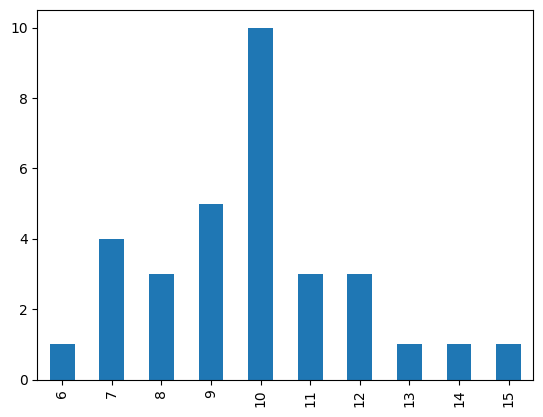

In [368]:
responses_indiv.value_counts().sort_index().plot(kind="bar");

In [369]:
indices, values = zip(*[(n, g["correct_response"].sum()) for n, g in df.groupby("stimulus")])

In [370]:
responses_piece = pd.Series(values, index=indices).sort_index()

Mean: 0.4460227272727273
Median:  0.421875


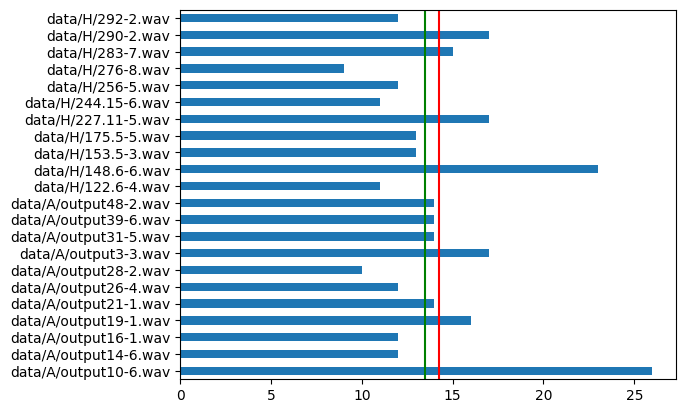

In [375]:
_, ax = plt.subplots()
responses_piece.plot(kind="barh", ax=ax)
avg = responses_piece.mean()
ax.axvline(avg, c="red")
ax.axvline(responses_piece.median(), c="green")
print("Mean:", responses_piece.mean() / 32)
print("Median: ", responses_piece.median() /32);

In [376]:
responses_A, responses_H = responses_piece[:11], responses_piece[11:]

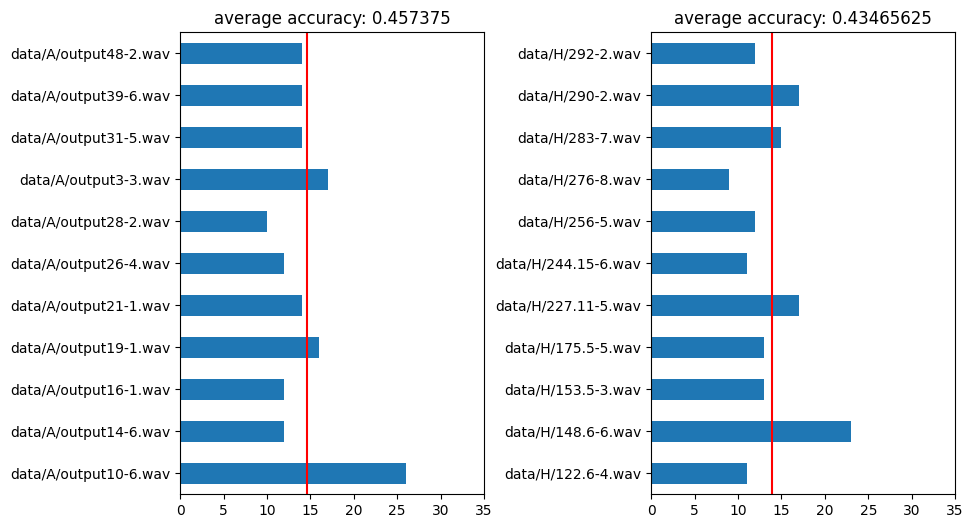

In [377]:
_, axes = plt.subplots(1,2, figsize=(10,6), gridspec_kw={"wspace": .55})
for i, r in enumerate([responses_A, responses_H]):
    r.plot(kind="barh", ax=axes[i])
    avg = round(r.mean(), 3)
    axes[i].axvline(avg, c="red")
    axes[i].set_title(f"average accuracy: {avg/32}")
    axes[i].set_xlim(0,35)
    

In [342]:
feedback = pd.Series([ eval(item)["Q0"] for item in list(survey_text["response"].values) if "Q0" in eval(item).keys() ])
for f in feedback.values:
    if f != "":
        print("-->", f.strip())

--> sehr gut
--> Coole idee, aber relativ schweres rätsel:)
--> War supi :)
--> die lieder klangen alle sehr gleich
--> scho schwer
--> sehr schwer, auch weil alle Stücke sehr ähnlich klangen
--> sehr schwer aber gut:)
--> Sehr interessant
--> Sehr kreativ und schön umgesetzt.
--> Megacoool und super innovativ, habt ihr echt super gemacht :)
--> es klingt alles wie von einer Maschine gespielt
--> schwer
--> sher gut
--> Es ist etwas schwierig zu unterscheiden zwischen KI & Mensch gemachte Musik, man kennt aber irgendwie den Muster. ist ein sehr gutes Experiment.
--> Die Aufgabe war schwierig, besonders weil bei den meisten Musikstücken die selben Instrumente erklangen interessant wäre auch ein Versuch mit unterschiedlichen Instrumenten.
--> Sehr schöner Test
--> schwierig und ohne Bachkenntnisse kaum lösbar
--> es hat total spaß gemacht auch wenn ich denke dass ich ziemlich viel falsch getippt habe. War eine super Erfahrung, da ich das ganze Thema rund um KI super spannend finde.
--> s

**Notizen**

- Alle Beispiele von Menschen einspielen lassen? Oder besser erklären, dass alles maschinell ab gespielt wird.
- Vergleichen: Einspielung vs Synthetisch?
- Bach-Choräle beliebt zum Trainieren, aber wenig Kontakt für Schüler. Wie funktioniert es bei "zugänglicheren" Sachen?
- Frage erweitern: Kann KI-Musik von menschlicher unterscheiden? Ausweitung der Genres etc.
- Notentext einbeziehen? --> Hypothese: Aufgabe wird leichter
- Mit SCB durchführen (oder Choräle spielen lassen)